# Final "Project"
Tren Meckel    
December 2024

This notebook connects to the 'nyc_flights' database,
retrieves flight data, and calculates the number of flights
per day of the week using Python's built-in datetime module.
This notebook also finds the number of flights per month, to 
see if there is any correlation between possible hoildays and 
increase of flights.


### *Import Statements*

In [558]:
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import text
import datetime
from collections import Counter
import re
from collections import defaultdict
import matplotlib.pyplot as plt

### *Query*    

In [560]:
def Query (query,db,credfilename):
    '''
    This function completes a query indicated by the "query" string passed in
    as a parameter.   The database name is also passed in as a parameter db.
    It is assumed there is a local file indicated by the credfilename
    with userid/password credentials for that database.  
    '''

    # create an empty dataframe as default return variable
    ret = pd.DataFrame()
    
    #=== First access userid/password credentials in creds dictionary
    defaults = {'user':'student2','password':'cs181_DA210!'}
    try:
        with open(credfilename,'r') as file:
            D = json.load(file)
            file.close()
            if D['mysql']:
                creds = D['mysql']
            else:
                creds = defaults
    except:
        creds = defaults

    #=== Create connection string
    template = 'mysql+mysqlconnector://{}:{}@jakku.cs.denison.edu/{}'
    cstring = template.format(creds['user'],creds['password'],db)
    #print(cstring)

    #=== Create engine connection
    engine = sa.create_engine(cstring)
    connection = engine.connect()

    #=== Execute query, get result
    resultproxy = connection.execute(text(query))
    rows = resultproxy.fetchall()
    cols = resultproxy.keys()
    ret = pd.DataFrame(rows,columns=cols)
    
    #=== closing the db connection
    connection.close()
    del engine

    return ret

### Query the database to retrieve raw flight data. --> esentially put the data into a form to work with


In [562]:
database = 'nyc_flights'
query = """
SELECT 
    year, 
    month, 
    day
FROM flights;
"""
data = Query(query, 'nyc_flights', 'creds.json')
#print(data)

### Process the retrieved data to calculate the day of the week.

In [563]:
# Convert query result to a list of dictionaries for easier processing
flights = [{"year": row[0], "month": row[1], "day": row[2]} for row in data.to_records(index=False)]

# Calculate day of the week for each flight
for flight in flights:
    year, month, day = flight["year"], flight["month"], flight["day"]
    flight_date = datetime.date(year, month, day)
    flight["day_of_week"] = flight_date.weekday()

# Aggregate counts of flights by day of the week
flight_counts = Counter(flight["day_of_week"] for flight in flights)


### Display the results

In [564]:
# Convert results to a sorted list of tuples (day_of_week, count)
sorted_flight_counts = sorted(flight_counts.items())

# Print the results
print("Day of Week | Flight Count")
for day_of_week, count in sorted_flight_counts:
    print(f"{day_mapping[day_of_week]}: {count} flights")

Day of Week | Flight Count
Monday: 50690 flights
Tuesday: 50422 flights
Wednesday: 50060 flights
Thursday: 50219 flights
Friday: 50308 flights
Saturday: 38720 flights
Sunday: 46357 flights


### Get number of flights by months

In [568]:
flights2 = [{"year": row[0], "month": row[1]} for row in data.to_records(index=False)]

# Count flights by month
month_counts = Counter(flight["month"] for flight in flights2)

month_names = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

sorted_month_counts = sorted(month_counts.items())

# Print the results
print("Month | Flight Count")
for month, count in sorted_month_counts:
    print(f"{month_names[month-1]}: {count} flights")

Month | Flight Count
January: 27004 flights
February: 24951 flights
March: 28834 flights
April: 28330 flights
May: 28796 flights
June: 28243 flights
July: 29425 flights
August: 29327 flights
September: 27574 flights
October: 28889 flights
November: 27268 flights
December: 28135 flights


### Take AirportCodes text file and parse it to get the airport code and state.

In [570]:
def parse_airport_codes(file_path):
    """Parse airport codes from the text file into a dictionary."""
    airport_data = {}
    current_category = None

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            
            # Detect category headers
            if line.startswith("UNITED STATES AIRPORT CODE LIST"):
                current_category = "US"
                airport_data[current_category] = []
            elif line.startswith("CANDIAN PROVINCES"):
                current_category = "Canada"
                airport_data[current_category] = []
            elif line.startswith("INTERNATIONAL CODE LIST"):
                current_category = "International"
                airport_data[current_category] = []
            elif current_category:
                # Parse airport entries
                match = re.match(r'^(.*?),\s*(.*?)\s+\((\w+)\)', line)
                if match:
                    city, region, code = match.groups()
                    airport_data[current_category].append((city, region, code))
    
    return airport_data


# Parse the text file
airport_data = parse_airport_codes("AirportCodes.txt")

# Convert to a dictionary mapping airport codes to states or countries
airport_to_category = {}
for category, airports in airport_data.items():
    for city, region, code in airports:
        airport_to_category[code] = region

# Check 
print(list(airport_to_category.items())[:5])

[('ABR', 'SD'), ('ABI', 'TX'), ('ADK', 'AK'), ('KKI', 'AK'), ('AKI', 'AK')]


### Get Airport Codes from SQL Library, of Origin and Destination

In [572]:
query2 = """
    SELECT origin, dest, COUNT(*) AS flight_count
    FROM flights
    GROUP BY origin, dest
    """

flight_data = Query(query2, 'nyc_flights', 'creds.json')
print(flight_data[:5])

  origin dest  flight_count
0    EWR  ALB           439
1    EWR  ANC             8
2    EWR  ATL          5022
3    EWR  AUS           968
4    EWR  AVL           265


#### This is to keep track of Airport codes found from SQL Library of the destination, and if those matches with either US, Candian Provinces or International airport codes to decipher whether or not the flights are going from States within U.S. or outside of the U.S. and keeping count

In [574]:
def map_flights_to_categories(flight_data, airport_to_category):
    """Map flights to categories (US, Canada, International) and count them."""
    distribution = {
        "US": 0,
        "Canada": 0,
        "International": 0,
    }

    for _, row in flight_data.iterrows():
        dest = row['dest']
        flight_count = row['flight_count']

        # Convert flight_count to integer
        try:
            flight_count = int(flight_count)
        except ValueError:
            print(f"Invalid flight count: {flight_count} for row: {row}")
            continue

        # Categorize the destination
        if dest in airport_to_category:
            if airport_to_category[dest] == "US":
                distribution["US"] += flight_count
            elif airport_to_category[dest] == "Canada":
                distribution["Canada"] += flight_count
            else:
                distribution["International"] += flight_count
    
    return distribution

### Attempt to put it into practice, see if distribution of airport codes were done correctly

In [576]:
# Count flights
distribution = map_flights_to_categories(flight_data, airport_to_category)

# Display results
print("Flight destination distribution:")
for category, count in distribution.items():
    print(f"{category}: {count}")

Flight destination distribution:
US: 0
Canada: 0
International: 321371


# Observations


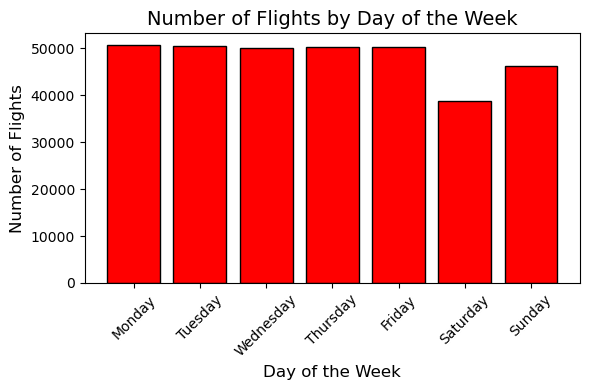

In [578]:
# Extract data for the plot
days_of_week = [day_mapping[day] for day, _ in sorted_flight_counts]
flight_counts = [count for _, count in sorted_flight_counts]

# Plot Graph
plt.figure(figsize=(6, 4))
plt.bar(days_of_week, flight_counts, color='red', edgecolor='black')
plt.title("Number of Flights by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It seems as from looking at this graph that across the days, there doesn't seem to be much difference between the days except on saturdays, it has a signifcantly less amount of flights which is interesting. I would think there would be more flights on Saturday since it is a weekend and people are more free on a weekend but it's less. 

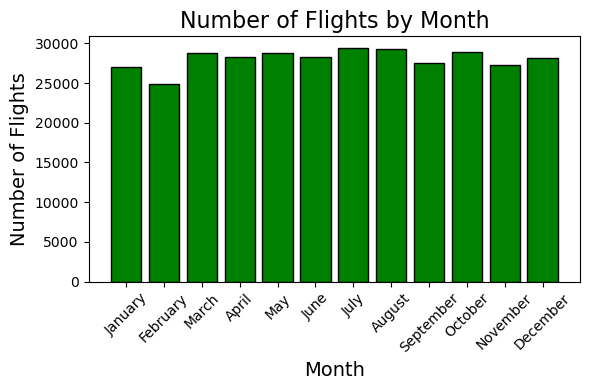

In [580]:
months = [month_names[month - 1] for month, _ in sorted_month_counts]
counts = [count for _, count in sorted_month_counts]

# Plot Graph
plt.figure(figsize=(6, 4))
plt.bar(months, counts, color='green', edgecolor='black')
plt.title("Number of Flights by Month", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Flights", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this graph it doesn't seem to be favoured towards any holiday for a signifcant number of increase in flights but we can see there are less flights in the beginning of the year for janurary and February even less. Maybe people don't feel the need to travel in the beginning of the year. 

#### Final Note
I could not figure out how to have the txt file and the airport SQL library work to where I could get the flights to show whether or not only U.S to U.S or outside, it seems they have all decided to group themselves under International. I think if I had more time to work on this without finals I'd be happy too but atlas. 